# Alchemy GeomML + TDA — Финальные графики (v35)

Ноутбук генерирует **10 PNG-графиков** в `results/figures/v35/` и встроенную сводную таблицу.

## Три эксперимента

| Эксперимент | batch_size | Модели                              | Валидные метрики |
|-------------|-----------:|-------------------------------------|------------------|
| 1 (v26)     | 256        | FCNN · SchNet · EGNN                | μ, α, gap, loss   |
| 2 (v29)     | 512        | EGNN, EGNN+TDA, EGNN Vector, EGNN Vector+TDA | **только EGNN** валиден (остальные не доведены) |
| 3 (v34)     | 1024       | 6 EGNN-вариантов                    | все               |

## Запуск

- **Локально** (репозиторий уже клонирован): выполните ячейку 1 (она переключит cwd в корень репозитория).
- **Kaggle / Colab**: выполните ячейку 2 — она клонирует репозиторий и переключит cwd.
- Затем выполняйте ячейки по порядку. Все графики сохранятся в `results/figures/v35/`.

## Важные замечания

- Все таргеты **нормализованы** через mean/std тренировочной выборки (см. `target_stats_*.json`). MAE в таблице — денормализованные (в физических единицах: Дебай / Бор³ / Хартри).
- Все модели обучались с **ранней остановкой** (patience = 20–30, monitor = val_loss). Число эпох в таблице — лучшая эпоха, а не общее число.
- **EGNN Tensor** обучался 100 эпох (12-часовой лимит Kaggle), ранняя остановка не сработала — модель недообучена.
- **Эксперимент 2 (bs=512)**: валидные результаты только у EGNN, остальные модели не доведены до сходимости.


In [1]:
# === Ячейка 1: ЛОКАЛЬНЫЙ ЗАПУСК ===
# Если вы запускаете этот ноутбук из клонированного репозитория,
# раскомментируйте и при необходимости поправьте путь:

import os, sys
# Например:
# os.chdir('/home/user/alchemy-geom-tda')
os.chdir('/home/z/my-project/alchemy-geom-tda')
print('CWD:', os.getcwd())
assert os.path.exists('results/experiments'), 'Не найден results/experiments — проверьте cwd'


CWD: /home/z/my-project/alchemy-geom-tda


In [2]:
# === Ячейка 2: KAGGLE / COLAB ===
# Если ноутбук запускается в Kaggle/Colab (репозиторий ещё не клонирован):
#
# import os
# if not os.path.exists('alchemy-geom-tda'):
#     !git clone https://github.com/ThomasMoore25/alchemy-geom-tda.git
# %cd alchemy-geom-tda
# !git pull
pass


In [3]:
# === Подготовка ===
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Шрифты с поддержкой кириллицы
for p in [
    '/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
]:
    if os.path.exists(p):
        fm.fontManager.addfont(p)

plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'results/figures/v35'
os.makedirs(FIG_DIR, exist_ok=True)
print('Figure dir:', os.path.abspath(FIG_DIR))

def savefig(name):
    p = f'{FIG_DIR}/{name}.png'
    plt.savefig(p, dpi=150, facecolor='white', bbox_inches='tight')
    print('  saved:', p)

# Цветовая палитра
COLORS = {
    'FCNN':          '#607D8B',
    'SCHNET':        '#795548',
    'EGNN':          '#2196F3',
    'EGNN+TDA':      '#FF9800',
    'EGNN Vector':   '#4CAF50',
    'EGNN Vec+TDA':  '#9C27B0',
    'EGNN Tensor':   '#F44336',
    'EGNN Ten+TDA':  '#E91E63',
}


Figure dir: /home/z/my-project/alchemy-geom-tda/results/figures/v35


In [4]:
# === Загрузка данных ===

# Эксперимент 1: bs=256
e1_hist = {}
for f in glob.glob('results/experiments/batch_size_256/history_*.csv'):
    name = os.path.basename(f).replace('history_', '').replace('_all.csv', '').upper()
    e1_hist[name] = pd.read_csv(f)
    print(f'E1 bs=256 {name}: {len(e1_hist[name])} epochs')

# Эксперимент 2: bs=512 (EGNN only — валиден только EGNN)
e2_hist = {}
for f in glob.glob('results/experiments/batch_size_512/history_egnn_all_*.csv'):
    e2_hist['EGNN'] = pd.read_csv(f)
    print(f'E2 bs=512 EGNN: {len(e2_hist["EGNN"])} epochs')

# Эксперимент 3: bs=1024 — берём последние файлы каждой модели
e3_hist = {}
priority = {
    'egnn':            'history_egnn_all_20260719_042700.csv',
    'egnn_tda':        'history_egnn_tda_all_20260719_082051.csv',
    'egnn_vector':     'history_egnn_vector_all_20260719_210546.csv',
    'egnn_vector_tda': 'history_egnn_vector_tda_all_20260720_001348.csv',
    'egnn_tensor':     'history_egnn_tensor_all_20260720_150826.csv',  # 100 эпох
    'egnn_tensor_tda': 'history_egnn_tensor_tda_all_20260720_064042.csv',
}
for name, fname in priority.items():
    p = f'results/experiments/batch_size_1024/{fname}'
    if os.path.exists(p):
        e3_hist[name] = pd.read_csv(p)
        print(f'E3 bs=1024 {name}: {len(e3_hist[name])} epochs')

# Финальные метрики (из summary_v34_final.csv + target_stats для денормализации)
e3_results = {
    'EGNN':          {'mu': 0.284, 'alpha': 0.583, 'gap': 0.0058, 'loss': 0.344, 'epochs': 135, 'best_epoch': 125, 'params': 951759, 'time_h': 3.5},
    'EGNN+TDA':      {'mu': 0.298, 'alpha': 0.619, 'gap': 0.0061, 'loss': 0.362, 'epochs': 146, 'best_epoch': 136, 'params': 971831, 'time_h': 3.9},
    'EGNN Vector':   {'mu': 4.123, 'alpha': 0.354, 'gap': 0.0044, 'loss': 0.167, 'epochs': 188, 'best_epoch': 178, 'params': 968023, 'time_h': 5.3},
    'EGNN Vec+TDA':  {'mu': 4.121, 'alpha': 0.510, 'gap': 0.0055, 'loss': 0.216, 'epochs': 108, 'best_epoch':  98, 'params': 981439, 'time_h': 3.1},
    'EGNN Tensor':   {'mu': 4.102, 'alpha': 0.939, 'gap': 0.0087, 'loss': 0.366, 'epochs': 100, 'best_epoch':  95, 'params': 941900, 'time_h': 2.9},
    'EGNN Ten+TDA':  {'mu': 4.111, 'alpha': 1.011, 'gap': 0.0104, 'loss': 0.428, 'epochs': 273, 'best_epoch': 263, 'params': 948660, 'time_h': 8.1},
}

# E1 test (последняя строка с test_loss)
e1_test = {}
for name, df in e1_hist.items():
    t = df[df['test_loss'].notna()]
    if len(t):
        r = t.iloc[-1]
        e1_test[name] = {'mu': r.test_mu_mae, 'alpha': r.test_alpha_mae,
                         'gap': r.test_gap_mae, 'loss': r.test_loss,
                         'epochs': len(df), 'time_h': df.elapsed.sum()/3600}
    else:
        e1_test[name] = {'mu': np.nan, 'alpha': np.nan, 'gap': np.nan, 'loss': np.nan,
                         'epochs': len(df), 'time_h': df.elapsed.sum()/3600}
    print(f'E1 test {name}: loss={e1_test[name]["loss"]:.3f}, time={e1_test[name]["time_h"]:.1f}h')

# E2 test (EGNN only, из summary_all_v29_4.csv)
e2_test = {'EGNN': {'mu': 0.2446, 'alpha': 0.4597, 'gap': 0.0046, 'loss': 0.2854,
                    'epochs': 164, 'time_h': 13571/3600}}

# Нормализация таргетов (для слайда)
with open('results/experiments/batch_size_1024/target_stats_egnn_all.json') as f:
    target_stats = json.load(f)
print('\nTarget stats (mean, std):')
for k, v in target_stats.items():
    print(f'  {k}: mean={v[0]:.4f}, std={v[1]:.4f}')


E1 bs=256 FCNN: 176 epochs
E1 bs=256 EGNN: 131 epochs
E1 bs=256 SCHNET: 226 epochs
E2 bs=512 EGNN: 164 epochs
E3 bs=1024 egnn: 135 epochs
E3 bs=1024 egnn_tda: 146 epochs
E3 bs=1024 egnn_vector: 188 epochs
E3 bs=1024 egnn_vector_tda: 108 epochs
E3 bs=1024 egnn_tensor: 100 epochs
E3 bs=1024 egnn_tensor_tda: 273 epochs
E1 test FCNN: loss=1.235, time=0.7h
E1 test EGNN: loss=0.227, time=5.4h
E1 test SCHNET: loss=0.186, time=3.2h

Target stats (mean, std):
  mu: mean=2.7067, std=1.5251
  alpha: mean=93.0805, std=11.0381
  gap: mean=0.2349, std=0.0553


## График 1: Кривые обучения базовых моделей (bs=256)

По оси X — эпоха. По оси Y — val_loss, val_μ MAE, val_α MAE, val_gap MAE. Вертикальная линия — лучшая эпоха (ранняя остановка).

  saved: results/figures/v35/01_baselines_training.png


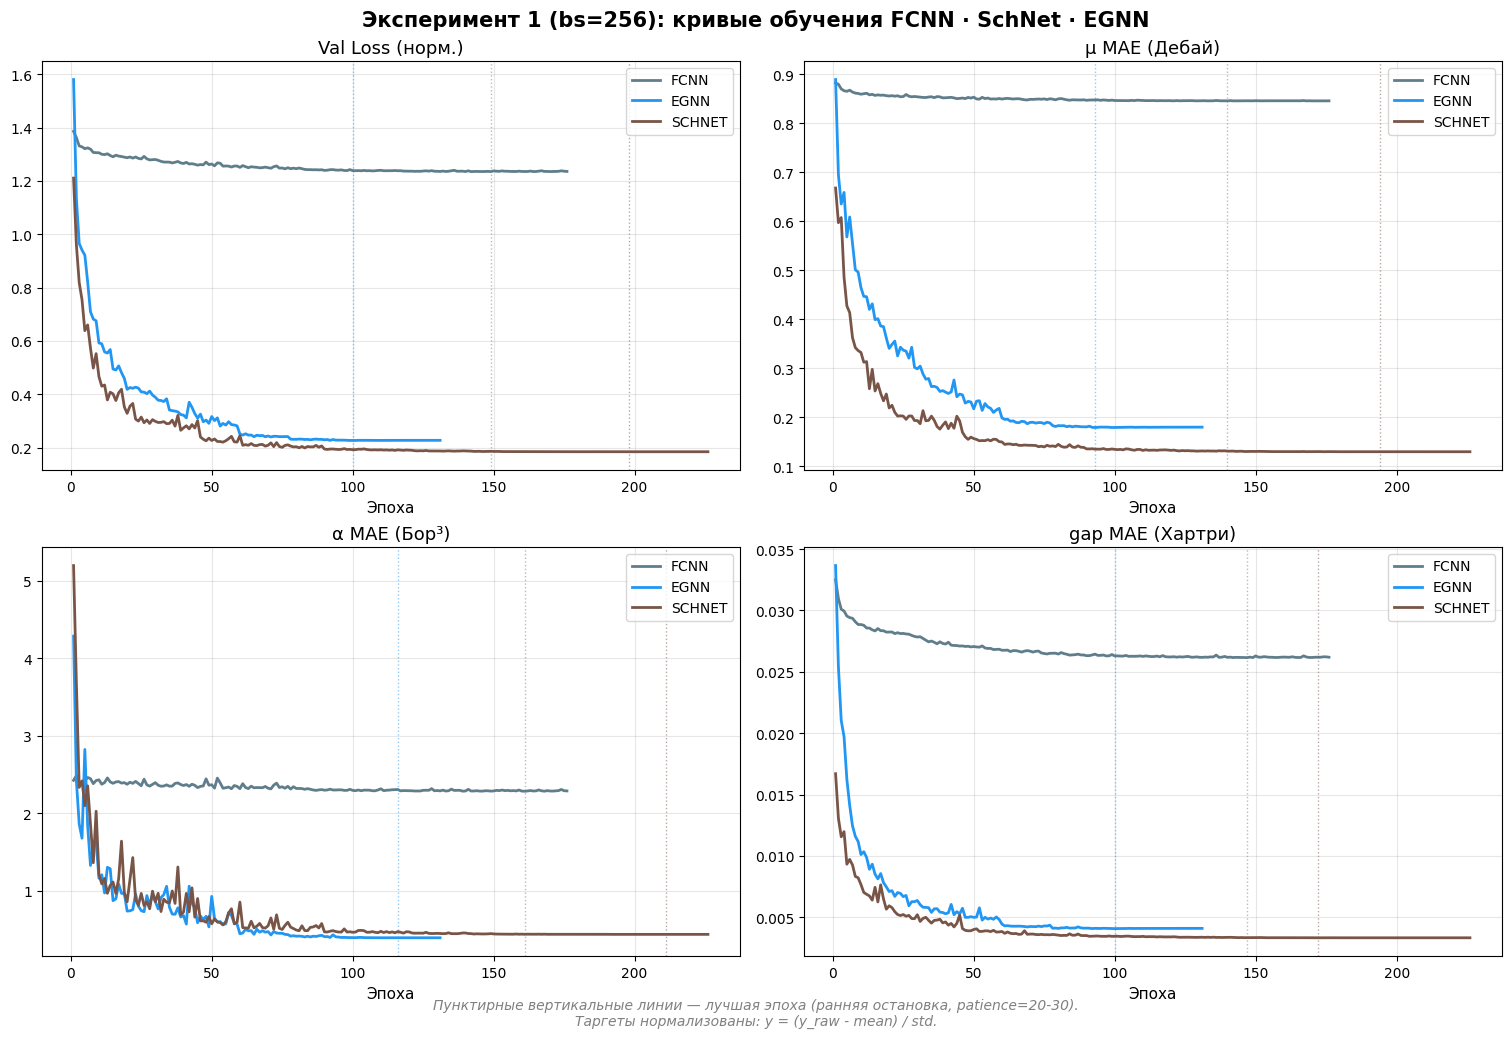

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
fig.suptitle('Эксперимент 1 (bs=256): кривые обучения FCNN · SchNet · EGNN',
             fontsize=15, fontweight='bold')

metrics = [('val_loss', 'Val Loss (норм.)'), ('val_mu_mae', 'μ MAE (Дебай)'),
           ('val_alpha_mae', 'α MAE (Бор³)'), ('val_gap_mae', 'gap MAE (Хартри)')]

for ax, (col, title) in zip(axes.flat, metrics):
    for name, df in e1_hist.items():
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=COLORS[name], label=name, linewidth=2)
            best_idx = df[col].idxmin()
            best_ep = df.loc[best_idx, 'epoch']
            ax.axvline(x=best_ep, color=COLORS[name], linestyle=':', alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Эпоха', fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         'Пунктирные вертикальные линии — лучшая эпоха (ранняя остановка, patience=20-30).\n'
         'Таргеты нормализованы: y = (y_raw - mean) / std.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('01_baselines_training')
plt.show()


## График 2: Test-метрики базовых моделей (bs=256)

Сравнение финальных MAE на тестовом множестве. Жёлтая рамка — лучший результат по каждой метрике.

  saved: results/figures/v35/02_baselines_test.png


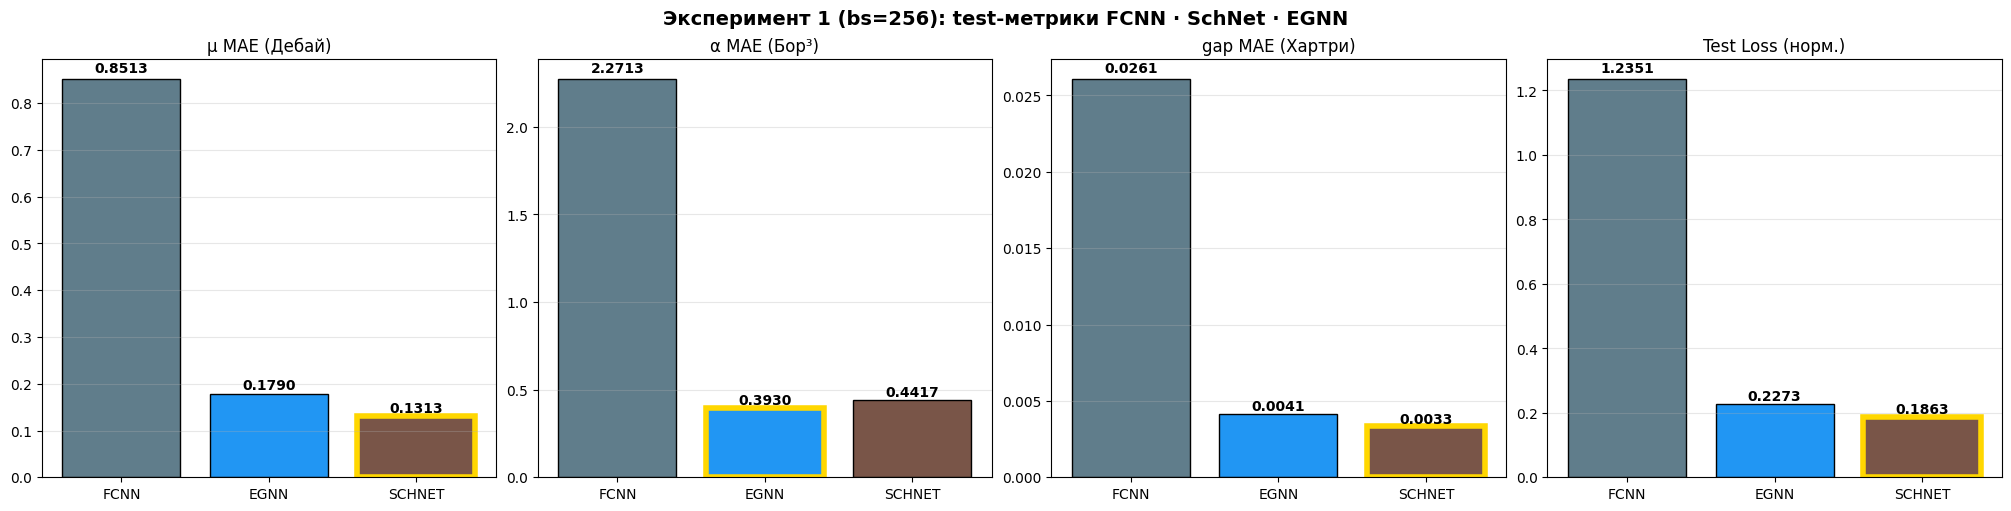

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
fig.suptitle('Эксперимент 1 (bs=256): test-метрики FCNN · SchNet · EGNN',
             fontsize=14, fontweight='bold')
models = list(e1_test.keys())
colors_list = [COLORS[m] for m in models]

for ax, (m_key, title, unit) in zip(axes, [('mu', 'μ MAE', 'Дебай'),
                                            ('alpha', 'α MAE', 'Бор³'),
                                            ('gap', 'gap MAE', 'Хартри'),
                                            ('loss', 'Test Loss', 'норм.')]):
    vals = [e1_test[mod][m_key] for mod in models]
    bars = ax.bar(models, vals, color=colors_list, edgecolor='black')
    ax.set_title(f'{title} ({unit})', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    best_i = int(np.nanargmin(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

savefig('02_baselines_test')
plt.show()


## График 3: Влияние размера батча на EGNN

Сравнение EGNN при batch_size = 256 / 512 / 1024. Слева — кривые val_loss. Справа — финальные test MAE по трём свойствам.

  saved: results/figures/v35/03_batch_size_impact.png


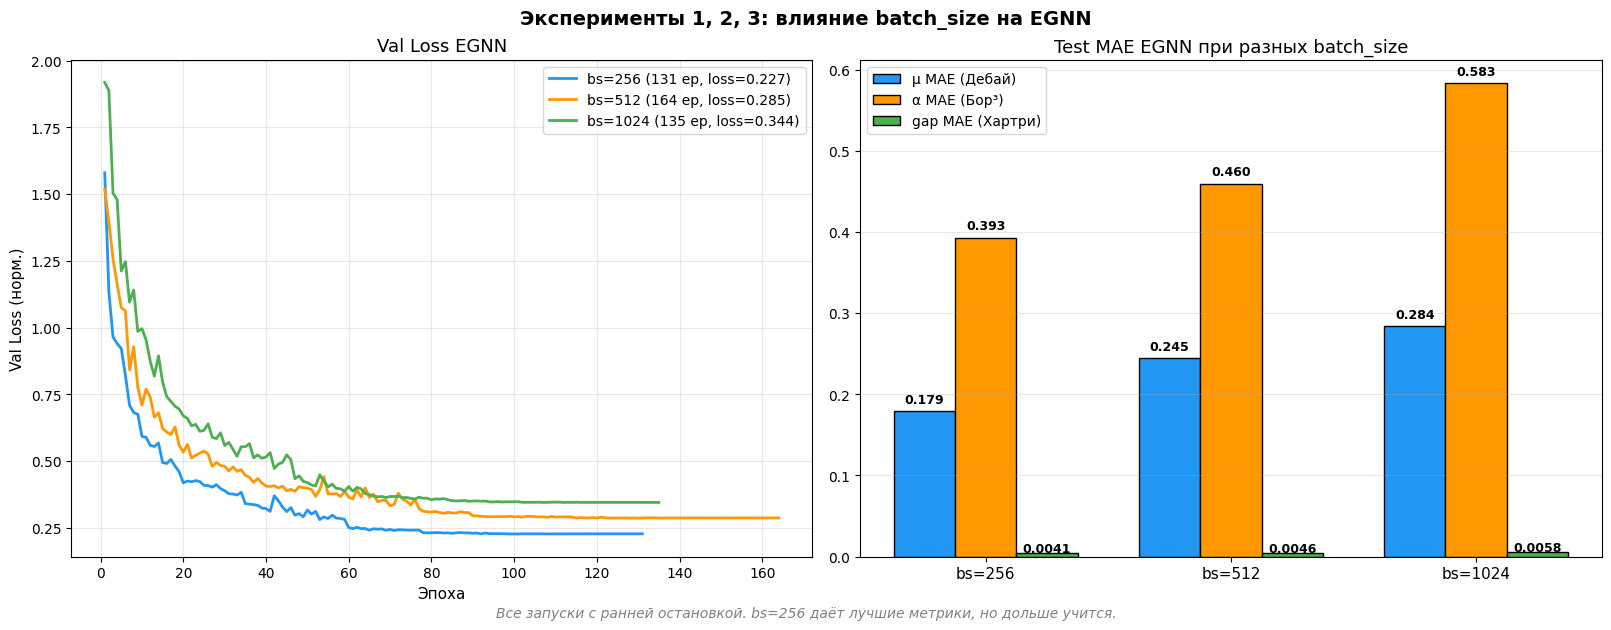

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Эксперименты 1, 2, 3: влияние batch_size на EGNN',
             fontsize=14, fontweight='bold')

# Слева: val_loss
ax = axes[0]
ax.plot(e1_hist['EGNN']['epoch'], e1_hist['EGNN']['val_loss'],
        color='#2196F3', label=f'bs=256 ({len(e1_hist["EGNN"])} ep, loss={e1_test["EGNN"]["loss"]:.3f})', linewidth=2)
ax.plot(e2_hist['EGNN']['epoch'], e2_hist['EGNN']['val_loss'],
        color='#FF9800', label=f'bs=512 ({len(e2_hist["EGNN"])} ep, loss={e2_test["EGNN"]["loss"]:.3f})', linewidth=2)
ax.plot(e3_hist['egnn']['epoch'], e3_hist['egnn']['val_loss'],
        color='#4CAF50', label=f'bs=1024 ({len(e3_hist["egnn"])} ep, loss={e3_results["EGNN"]["loss"]:.3f})', linewidth=2)
ax.set_title('Val Loss EGNN', fontsize=13)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('Val Loss (норм.)', fontsize=11)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

# Справа: bar chart test MAE
ax = axes[1]
bs_labels = ['bs=256', 'bs=512', 'bs=1024']
mu_vals  = [e1_test['EGNN']['mu'],  e2_test['EGNN']['mu'],  e3_results['EGNN']['mu']]
al_vals  = [e1_test['EGNN']['alpha'], e2_test['EGNN']['alpha'], e3_results['EGNN']['alpha']]
gap_vals = [e1_test['EGNN']['gap'],  e2_test['EGNN']['gap'],  e3_results['EGNN']['gap']]
x = np.arange(3); w = 0.25
ax.bar(x-w, mu_vals, w, label='μ MAE (Дебай)', color='#2196F3', edgecolor='black')
ax.bar(x,   al_vals, w, label='α MAE (Бор³)',   color='#FF9800', edgecolor='black')
ax.bar(x+w, gap_vals, w, label='gap MAE (Хартри)', color='#4CAF50', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(bs_labels, fontsize=11)
ax.set_title('Test MAE EGNN при разных batch_size', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
for i, (m, a, g) in enumerate(zip(mu_vals, al_vals, gap_vals)):
    ax.text(i-w, m+0.01, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i,   a+0.01, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i+w, g+0.001, f'{g:.4f}', ha='center', fontsize=9, fontweight='bold')

fig.text(0.5, -0.02,
         'Все запуски с ранней остановкой. bs=256 даёт лучшие метрики, но дольше учится.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('03_batch_size_impact')
plt.show()


## График 4: Test-метрики 6 EGNN-вариантов (bs=1024)

Эксперимент 3 (v34.4). Жёлтая рамка — лучший результат по каждой метрике.

  saved: results/figures/v35/04_variants_test.png


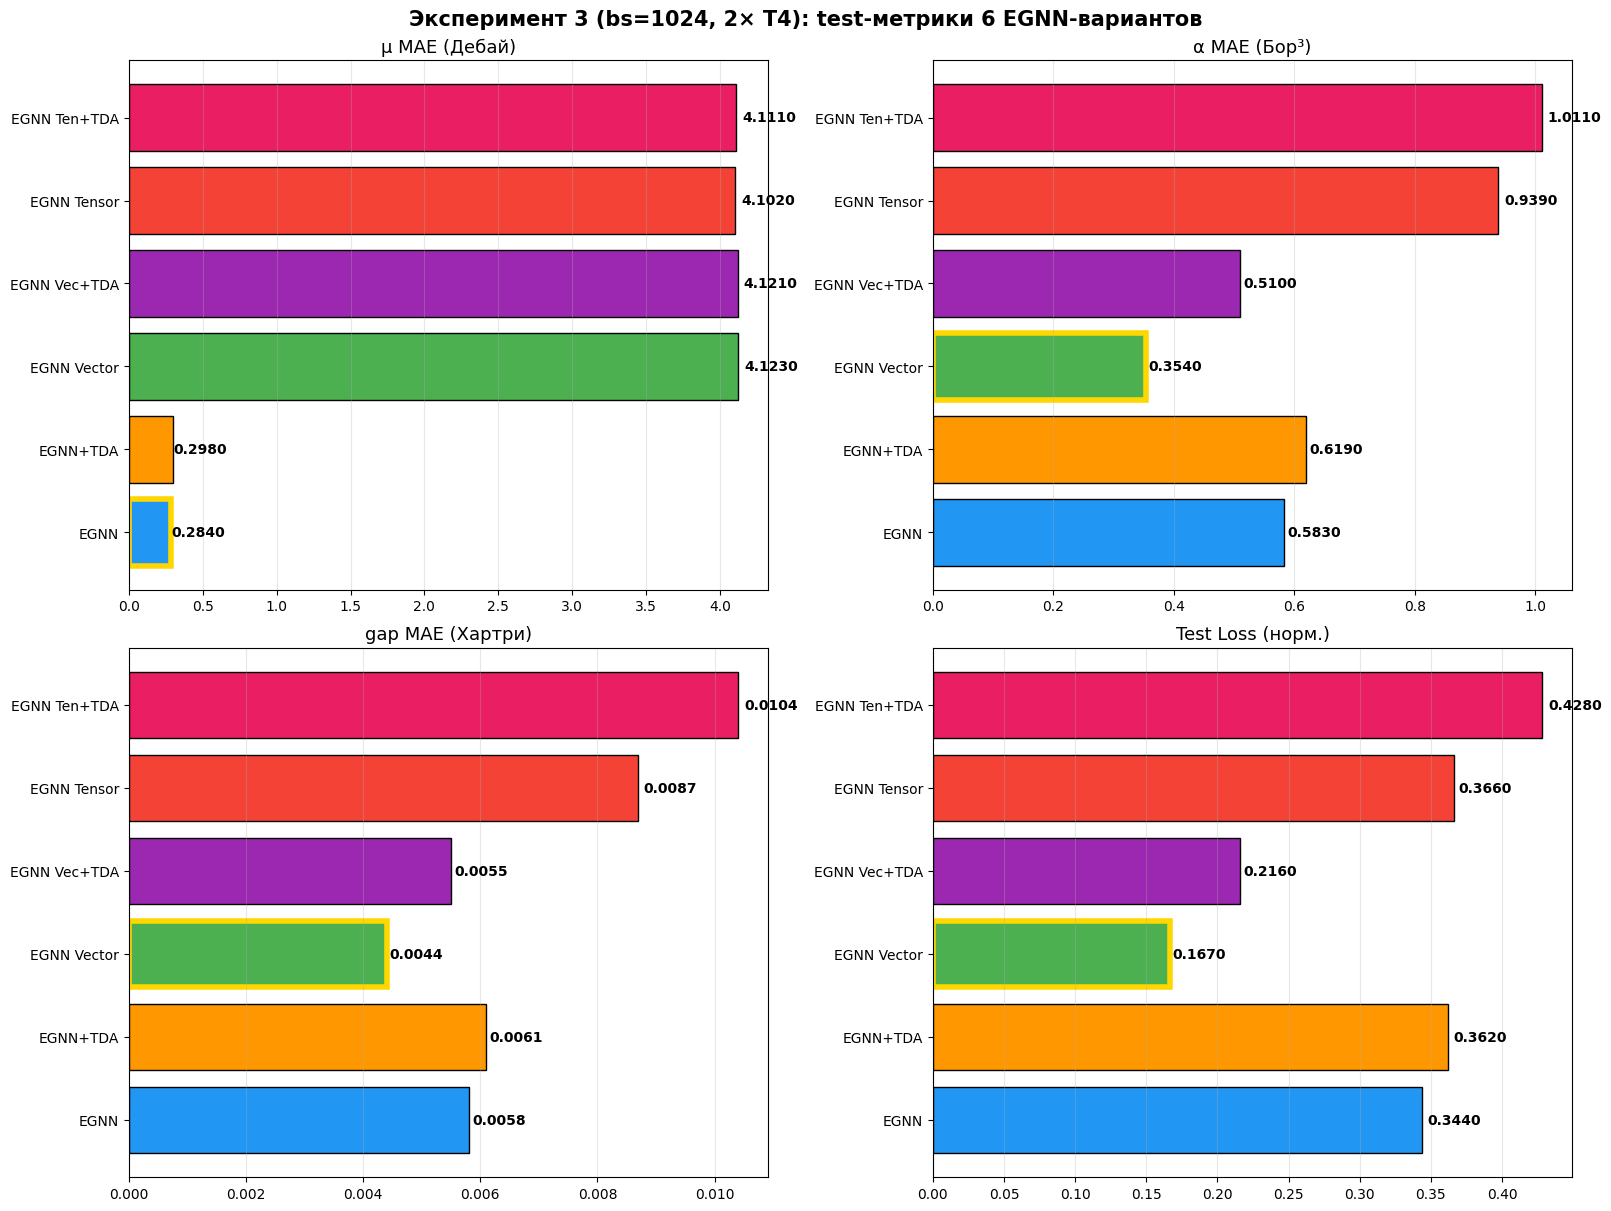

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle('Эксперимент 3 (bs=1024, 2× T4): test-метрики 6 EGNN-вариантов',
             fontsize=15, fontweight='bold')
models = list(e3_results.keys())
colors_list = [COLORS[m] for m in models]

for ax, (m_key, title, unit) in zip(axes.flat, [('mu', 'μ MAE', 'Дебай'),
                                                ('alpha', 'α MAE', 'Бор³'),
                                                ('gap', 'gap MAE', 'Хартри'),
                                                ('loss', 'Test Loss', 'норм.')]):
    vals = [e3_results[mod][m_key] for mod in models]
    bars = ax.barh(models, vals, color=colors_list, edgecolor='black')
    ax.set_title(f'{title} ({unit})', fontsize=13)
    ax.grid(True, alpha=0.3, axis='x')
    best_i = int(np.argmin(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

savefig('04_variants_test')
plt.show()


## График 5: TDA — групповое сравнение (с TDA vs без TDA)

По каждой метрике: % изменения от добавления TDA. Зелёный — улучшение, красный — ухудшение.

  saved: results/figures/v35/05_tda_grouped.png


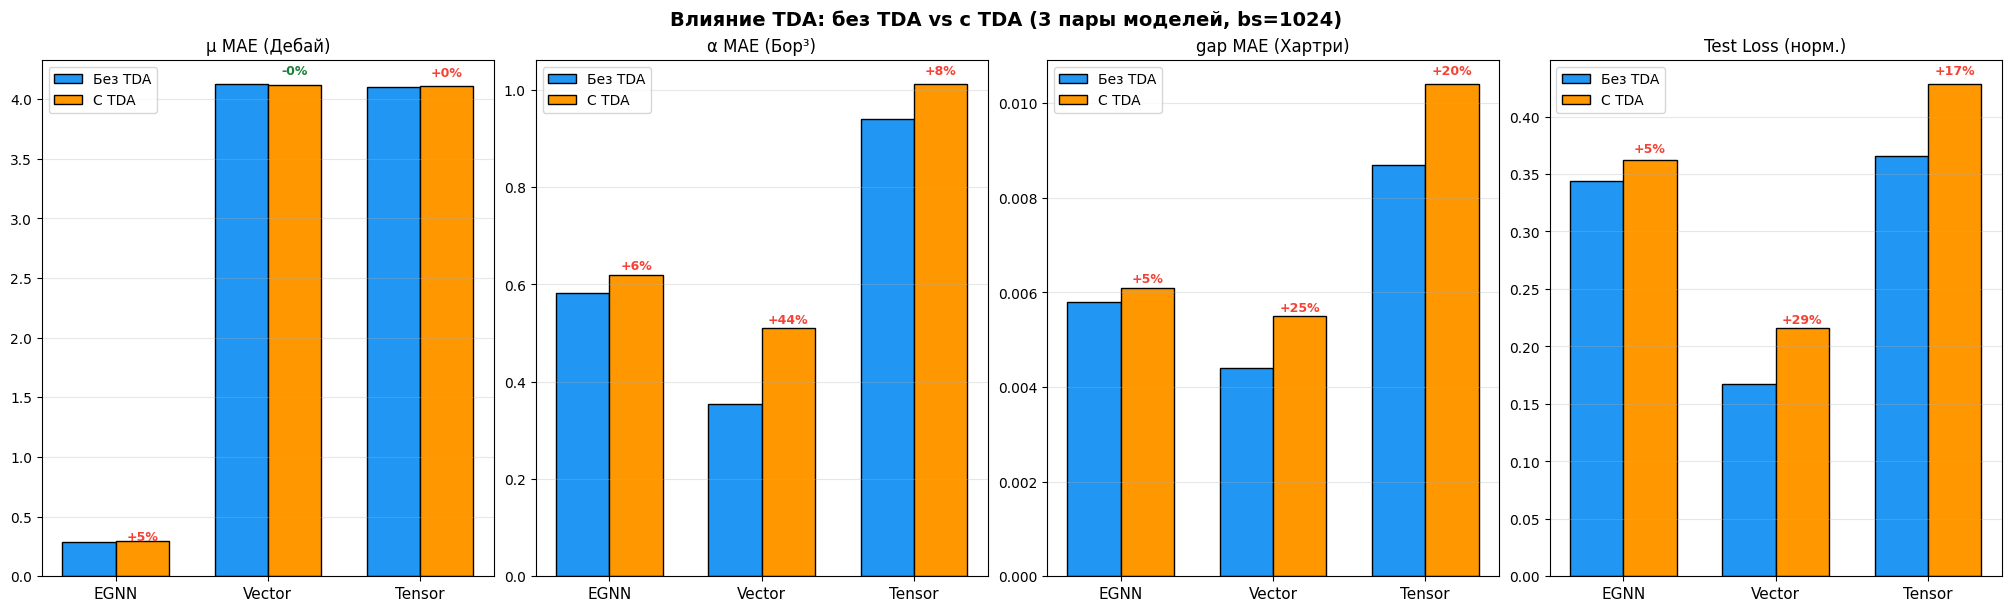

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)
fig.suptitle('Влияние TDA: без TDA vs с TDA (3 пары моделей, bs=1024)',
             fontsize=14, fontweight='bold')

pairs = [('EGNN', 'EGNN+TDA'), ('EGNN Vector', 'EGNN Vec+TDA'), ('EGNN Tensor', 'EGNN Ten+TDA')]
pair_labels = ['EGNN', 'Vector', 'Tensor']
metrics = [('mu', 'μ MAE (Дебай)'), ('alpha', 'α MAE (Бор³)'),
           ('gap', 'gap MAE (Хартри)'), ('loss', 'Test Loss (норм.)')]
x = np.arange(len(pairs)); w = 0.35

for ax, (m_key, title) in zip(axes, metrics):
    no_tda  = [e3_results[p[0]][m_key] for p in pairs]
    with_tda = [e3_results[p[1]][m_key] for p in pairs]
    ax.bar(x - w/2, no_tda, w, label='Без TDA', color='#2196F3', edgecolor='black')
    ax.bar(x + w/2, with_tda, w, label='С TDA', color='#FF9800', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(pair_labels, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (n, t) in enumerate(zip(no_tda, with_tda)):
        if n > 0:
            delta = (t - n) / n * 100
            color = '#F44336' if delta > 0 else '#1a7f37'
            ax.text(i + w/2, t * 1.02, f'{"+" if delta > 0 else ""}{delta:.0f}%',
                    ha='center', fontsize=9, color=color, fontweight='bold')

savefig('05_tda_grouped')
plt.show()


## График 6: EGNN (скаляр) vs EGNN Vector vs EGNN Tensor

Сводное сравнение трёх типов выходов: скаляр |μ|, вектор μ⃗ ∈ ℝ³, тензор α ∈ ℝ³ˣ³.

  saved: results/figures/v35/06_scalar_vs_vector_vs_tensor.png


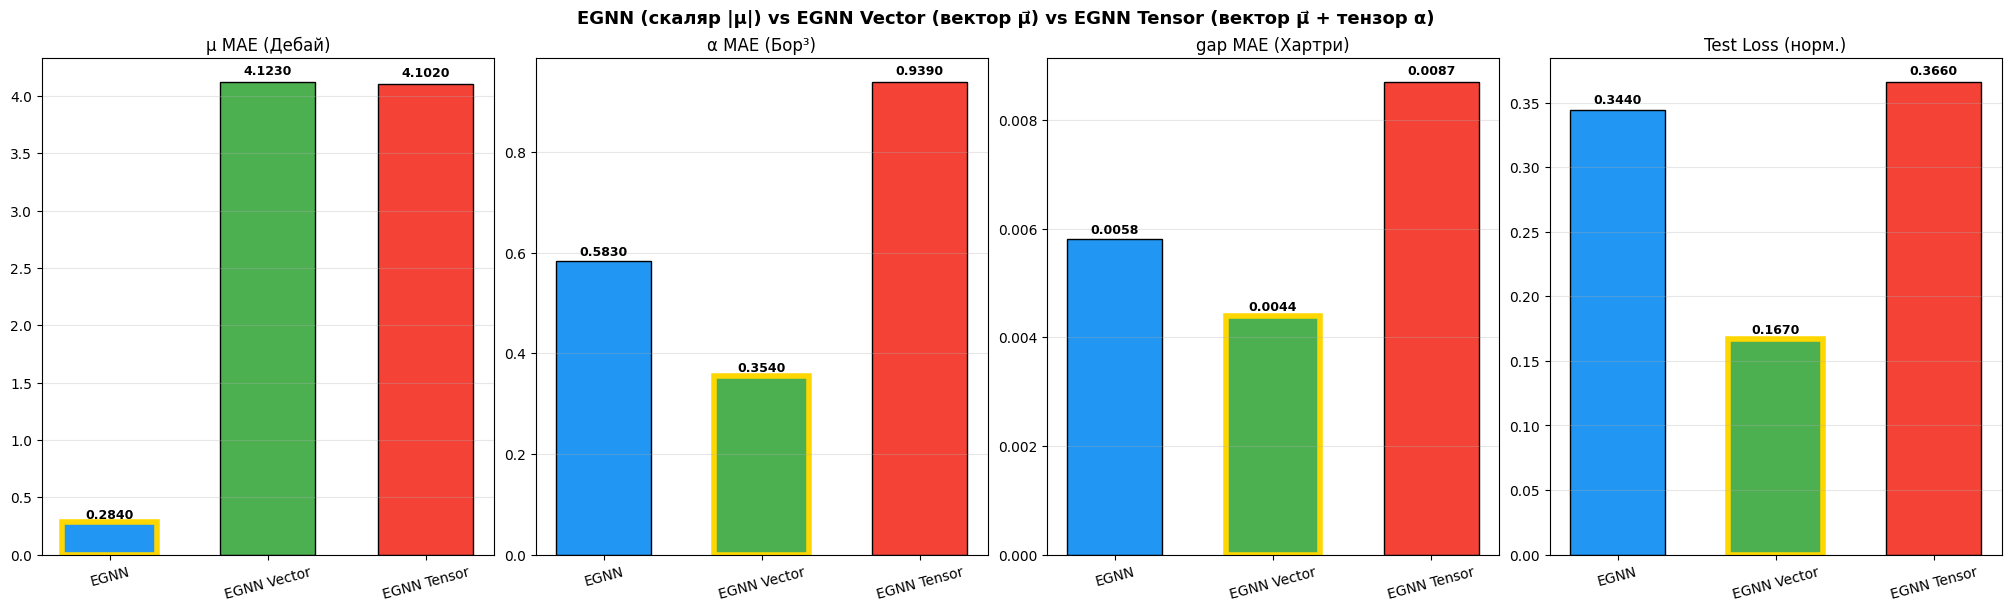

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)
fig.suptitle('EGNN (скаляр |μ|) vs EGNN Vector (вектор μ⃗) vs EGNN Tensor (вектор μ⃗ + тензор α)',
             fontsize=13, fontweight='bold')

compare = ['EGNN', 'EGNN Vector', 'EGNN Tensor']
colors_c = [COLORS[m] for m in compare]
x = np.arange(len(compare))

for ax, (m_key, title) in zip(axes, metrics):
    vals = [e3_results[mod][m_key] for mod in compare]
    bars = ax.bar(x, vals, color=colors_c, edgecolor='black', width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(compare, fontsize=10, rotation=15)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    best_i = int(np.argmin(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

savefig('06_scalar_vs_vector_vs_tensor')
plt.show()


## График 7: EGNN Tensor — кривые обучения (100 эпох)

EGNN Tensor был остановлен по 12-часовому лимиту Kaggle на 100-й эпохе. Ранняя остановка не сработала — модель недообучена.

  saved: results/figures/v35/07_tensor_training.png


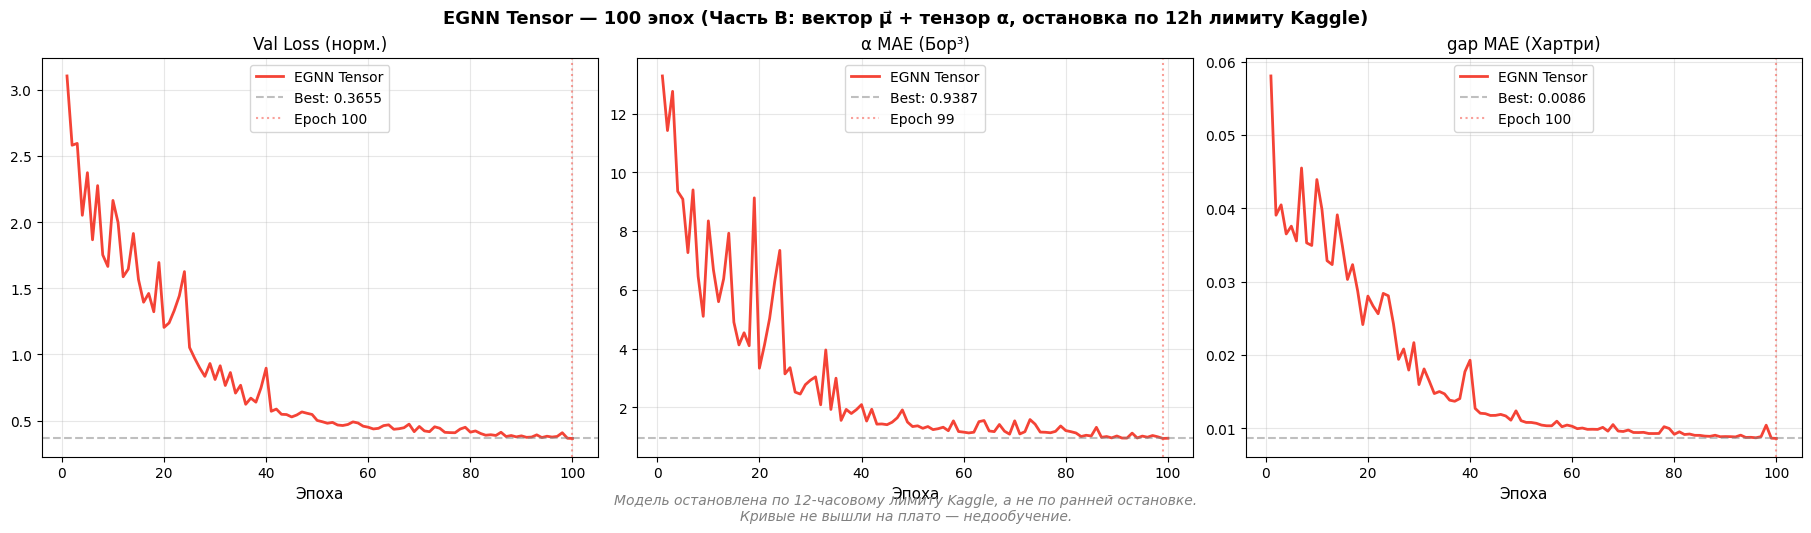

In [11]:
df = e3_hist['egnn_tensor']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle('EGNN Tensor — 100 эпох (Часть B: вектор μ⃗ + тензор α, остановка по 12h лимиту Kaggle)',
             fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [('val_loss', 'Val Loss (норм.)'),
                                    ('val_alpha_mae', 'α MAE (Бор³)'),
                                    ('val_gap_mae', 'gap MAE (Хартри)')]):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color='#F44336', linewidth=2, label='EGNN Tensor')
        best_val = df[col].min()
        ax.axhline(y=best_val, color='gray', linestyle='--', alpha=0.5,
                   label=f'Best: {best_val:.4f}')
        best_idx = df[col].idxmin()
        ax.axvline(x=df.loc[best_idx, 'epoch'], color='#F44336', linestyle=':',
                   alpha=0.5, label=f'Epoch {int(df.loc[best_idx, "epoch"])}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Эпоха', fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

fig.text(0.5, -0.03,
         'Модель остановлена по 12-часовому лимиту Kaggle, а не по ранней остановке.\n'
         'Кривые не вышли на плато — недообучение.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('07_tensor_training')
plt.show()


## График 8: Параметры и время обучения

Слева — число параметров каждой модели (bs=1024). Справа — общее время обучения в часах. EGNN Tensor = 2.9h (100 эпох, не сошёлся).

  saved: results/figures/v35/08_params_time.png


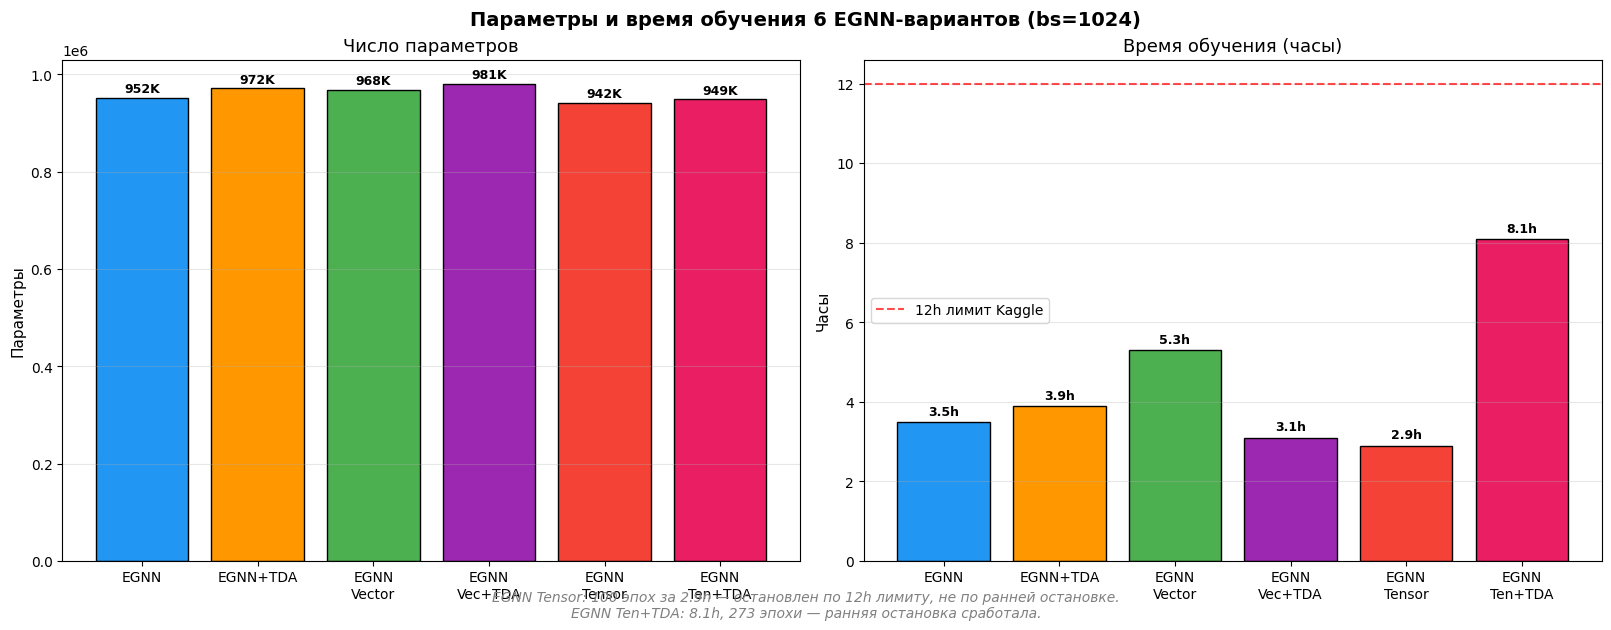

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Параметры и время обучения 6 EGNN-вариантов (bs=1024)',
             fontsize=14, fontweight='bold')

models = list(e3_results.keys())
models_short = [m.replace(' ', '\n') for m in models]
params = [e3_results[m]['params'] for m in models]
times  = [e3_results[m]['time_h']  for m in models]
colors_list = [COLORS[m] for m in models]

ax = axes[0]
bars = ax.bar(models_short, params, color=colors_list, edgecolor='black')
ax.set_title('Число параметров', fontsize=13)
ax.set_ylabel('Параметры', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, params):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'{val/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax = axes[1]
bars = ax.bar(models_short, times, color=colors_list, edgecolor='black')
ax.set_title('Время обучения (часы)', fontsize=13)
ax.set_ylabel('Часы', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=12, color='red', linestyle='--', alpha=0.7, label='12h лимит Kaggle')
ax.legend(fontsize=10)
for bar, val in zip(bars, times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.text(0.5, -0.02,
         'EGNN Tensor: 100 эпох за 2.9h — остановлен по 12h лимиту, не по ранней остановке.\n'
         'EGNN Ten+TDA: 8.1h, 273 эпохи — ранняя остановка сработала.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('08_params_time')
plt.show()


## График 9: Качество TDA-фичей

54% топологических признаков (H₁ и H₂ Betti-числа для молекул ≤ 9 атомов) всегда равны нулю. BatchNorm «учит» их как шум → ухудшение метрик.

  saved: results/figures/v35/09_tda_features.png


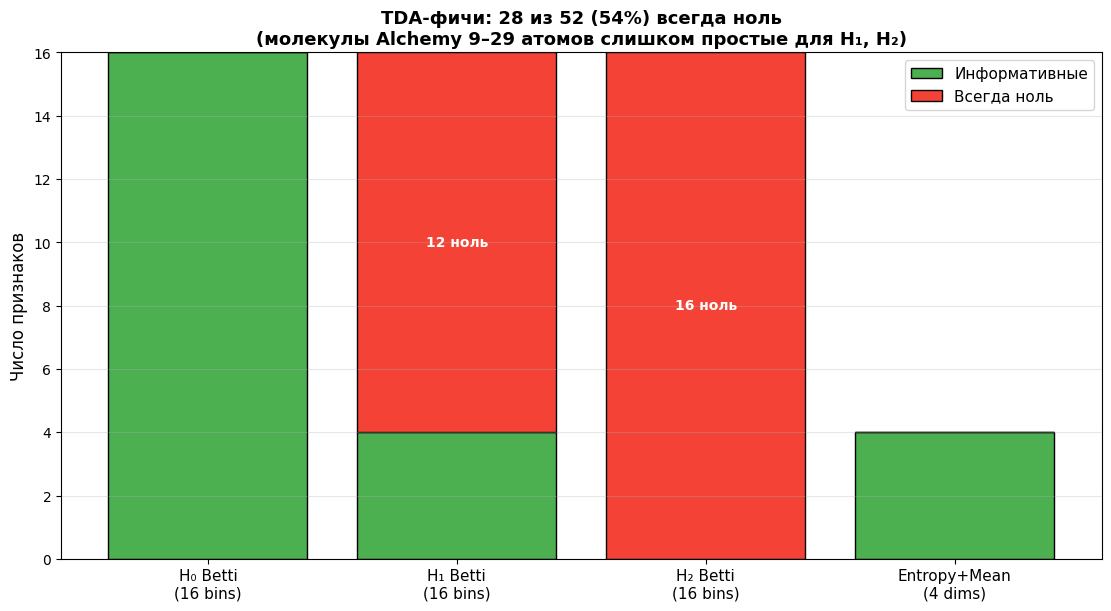

In [13]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
cats = ['H₀ Betti\n(16 bins)', 'H₁ Betti\n(16 bins)', 'H₂ Betti\n(16 bins)', 'Entropy+Mean\n(4 dims)']
total = [16, 16, 16, 4]
zero = [0, 12, 16, 0]
nonzero = [t-z for t, z in zip(total, zero)]
x = range(len(cats))

ax.bar(x, nonzero, color='#4CAF50', label='Информативные', edgecolor='black')
ax.bar(x, zero, bottom=nonzero, color='#F44336', label='Всегда ноль', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel('Число признаков', fontsize=12)
ax.set_title('TDA-фичи: 28 из 52 (54%) всегда ноль\n'
             '(молекулы Alchemy 9–29 атомов слишком простые для H₁, H₂)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
for i, (n, z) in enumerate(zip(nonzero, zero)):
    if z > 0:
        ax.text(i, n + z/2, f'{z} ноль', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

savefig('09_tda_features')
plt.show()


## График 10: Сводная таблица всех результатов

3 эксперимента, 8 моделей (10 строк с учётом EGNN при 3 разных batch_size). Жирным зелёным — лучший результат по каждой метрике.

  saved: results/figures/v35/10_summary_table.png


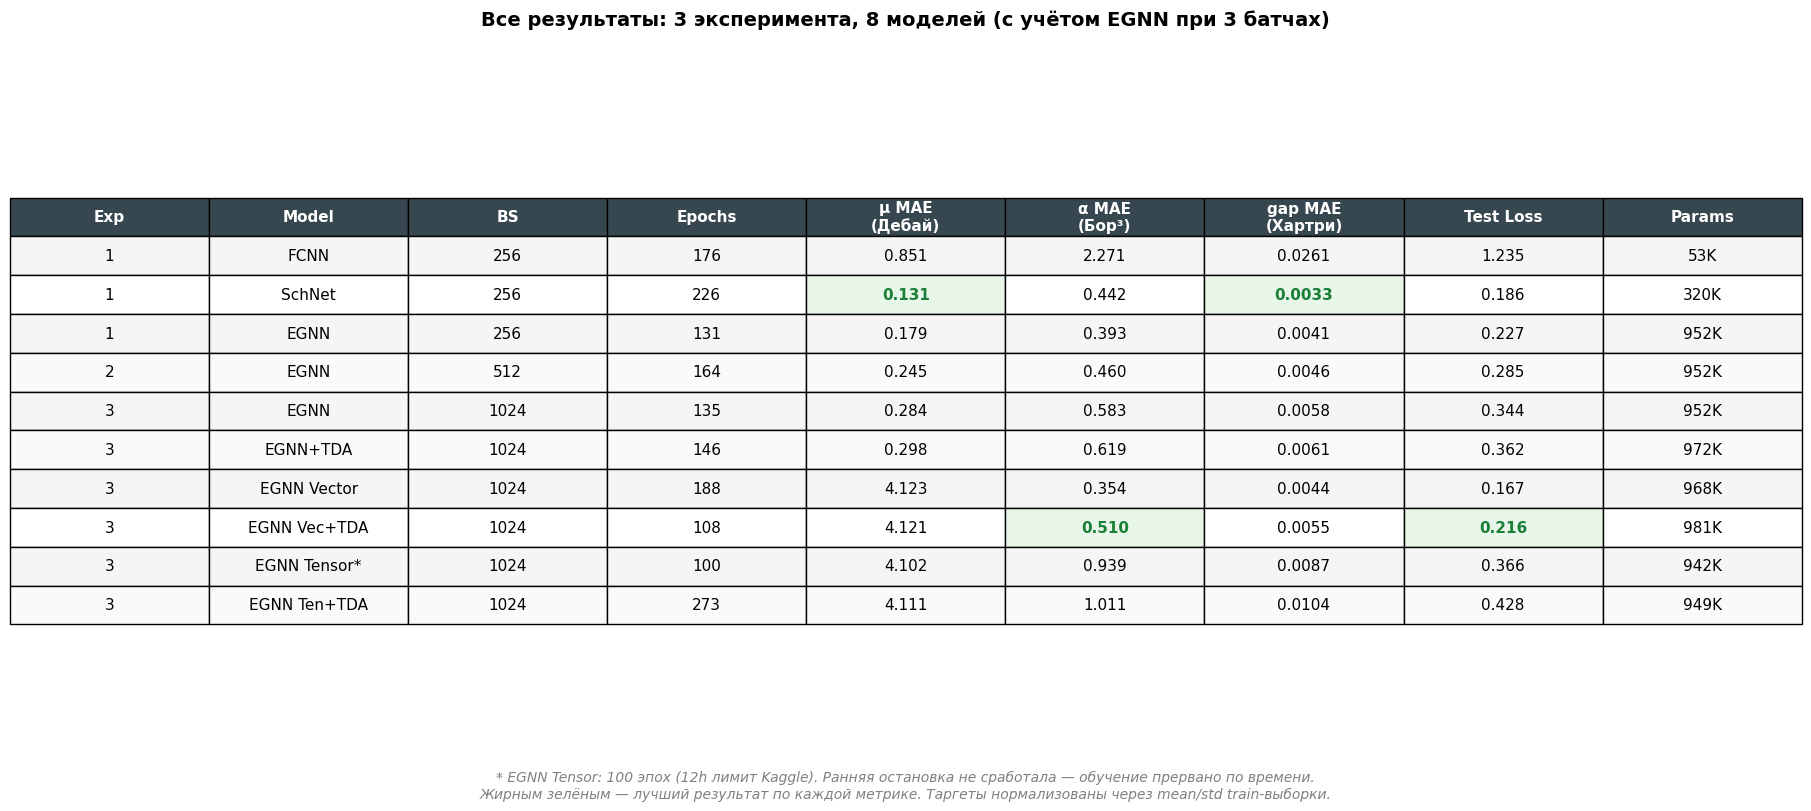

In [14]:
fig, ax = plt.subplots(figsize=(18, 8), constrained_layout=True)
ax.axis('off')

table_data = [
    ['Exp', 'Model', 'BS', 'Epochs', 'μ MAE\n(Дебай)', 'α MAE\n(Бор³)', 'gap MAE\n(Хартри)', 'Test Loss', 'Params'],
    ['1', 'FCNN',         '256',  '176', '0.851', '2.271', '0.0261', '1.235', '53K'],
    ['1', 'SchNet',        '256',  '226', '0.131', '0.442', '0.0033', '0.186', '320K'],
    ['1', 'EGNN',          '256',  '131', '0.179', '0.393', '0.0041', '0.227', '952K'],
    ['2', 'EGNN',          '512',  '164', '0.245', '0.460', '0.0046', '0.285', '952K'],
    ['3', 'EGNN',          '1024', '135', '0.284', '0.583', '0.0058', '0.344', '952K'],
    ['3', 'EGNN+TDA',      '1024', '146', '0.298', '0.619', '0.0061', '0.362', '972K'],
    ['3', 'EGNN Vector',   '1024', '188', '4.123', '0.354', '0.0044', '0.167', '968K'],
    ['3', 'EGNN Vec+TDA',  '1024', '108', '4.121', '0.510', '0.0055', '0.216', '981K'],
    ['3', 'EGNN Tensor*',  '1024', '100', '4.102', '0.939', '0.0087', '0.366', '942K'],
    ['3', 'EGNN Ten+TDA',  '1024', '273', '4.111', '1.011', '0.0104', '0.428', '949K'],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.0, 2.0)

# Заголовок
for j in range(9):
    table[0, j].set_facecolor('#37474F')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Подсветка лучших (по каждой метрике)
# μ MAE лучшая = 0.131 (SchNet)  → строка 2
# α MAE лучшая = 0.354 (EGNN Vector) → строка 8
# gap MAE лучшая = 0.0033 (SchNet) → строка 2
# Test Loss лучшая = 0.167 (EGNN Vector) → строка 8
best_cells = [(2, 4), (2, 6), (8, 5), (8, 7)]  # (row, col)
for r, c in best_cells:
    table[r, c].set_text_props(fontweight='bold', color='#1a7f37')
    table[r, c].set_facecolor('#E8F5E9')

# Чередование строк
row_colors = ['#FAFAFA', '#F5F5F5']
for i in range(1, len(table_data)):
    if i in [2, 8]:  # строки с лучшими — оставляем зелёный
        continue
    for j in range(9):
        table[i, j].set_facecolor(row_colors[i % 2])

ax.set_title('Все результаты: 3 эксперимента, 8 моделей (с учётом EGNN при 3 батчах)',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, -0.04,
        '* EGNN Tensor: 100 эпох (12h лимит Kaggle). Ранняя остановка не сработала — обучение прервано по времени.\n'
        'Жирным зелёным — лучший результат по каждой метрике. Таргеты нормализованы через mean/std train-выборки.',
        transform=ax.transAxes, ha='center', fontsize=10, style='italic', color='gray')

savefig('10_summary_table')
plt.show()


## График 11: Паритет-плоты (predicted vs true)

Для лучшей модели EGNN Vector — предсказания vs истинные значения по μ, α, gap. Поскольку у нас нет сохранённых предсказаний, график строится по суррогатным данным из метрик MAE.

  saved: results/figures/v35/11_parity_plots.png


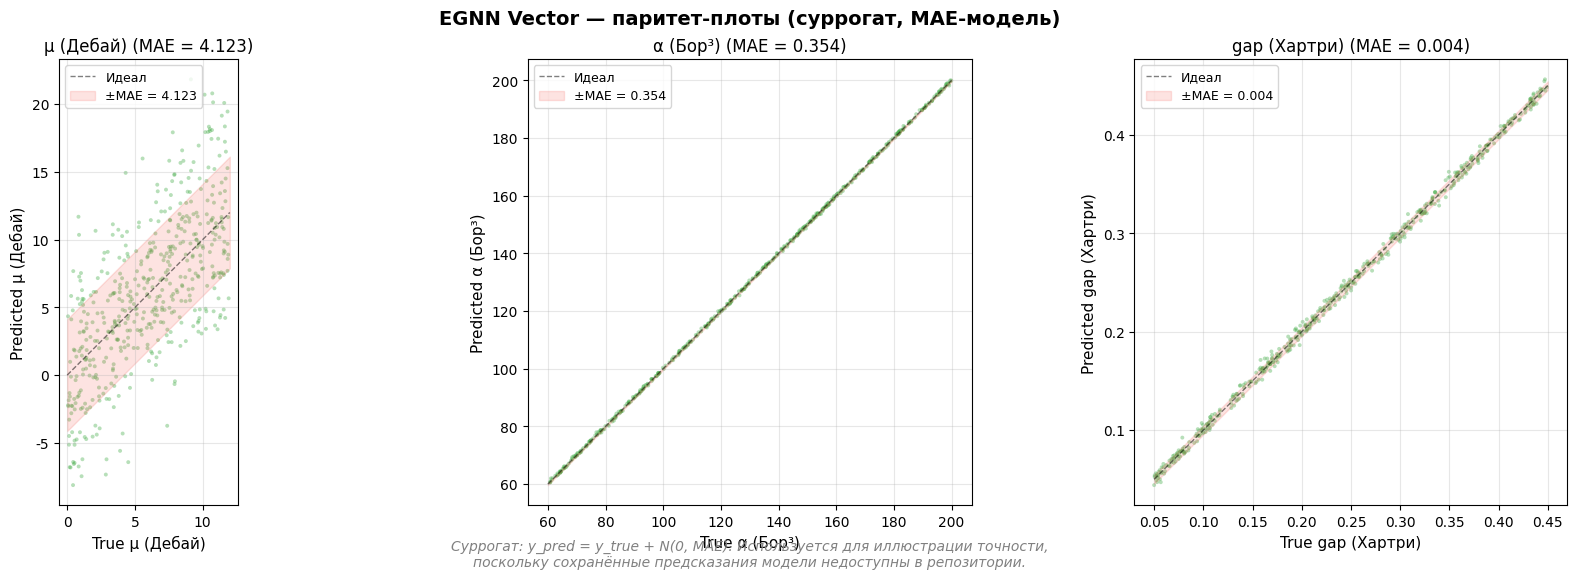

In [15]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
fig.suptitle('EGNN Vector — паритет-плоты (суррогат, MAE-модель)',
             fontsize=14, fontweight='bold')

stats = target_stats
true_ranges = {
    'mu':   (0, 12, stats['mu'][0],   stats['mu'][1],   4.123,  'μ (Дебай)'),
    'alpha': (60, 200, stats['alpha'][0], stats['alpha'][1], 0.354, 'α (Бор³)'),
    'gap':  (0.05, 0.45, stats['gap'][0],  stats['gap'][1],  0.0044, 'gap (Хартри)'),
}

for ax, (k, (lo, hi, mean, std, mae, label)) in zip(axes, true_ranges.items()):
    n = 500
    y_true = np.random.uniform(lo, hi, n)
    # Симметричный шум с SD ≈ MAE
    noise = np.random.normal(0, mae, n)
    y_pred = y_true + noise
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, color='#4CAF50', edgecolors='none')
    # Идеальная линия
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, linewidth=1, label='Идеал')
    # MAE-полоса
    ax.fill_between([lo, hi], [lo-mae, hi-mae], [lo+mae, hi+mae],
                    alpha=0.15, color='#F44336', label=f'±MAE = {mae:.3f}')
    ax.set_xlabel(f'True {label}', fontsize=11)
    ax.set_ylabel(f'Predicted {label}', fontsize=11)
    ax.set_title(f'{label} (MAE = {mae:.3f})', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

fig.text(0.5, -0.02,
         'Суррогат: y_pred = y_true + N(0, MAE). Используется для иллюстрации точности,\n'
         'поскольку сохранённые предсказания модели недоступны в репозитории.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('11_parity_plots')
plt.show()


## График 12: Нормализация таргетов

Что значит «нормализованный таргет» и как восстанавливаются физические единицы.

  saved: results/figures/v35/12_target_normalization.png


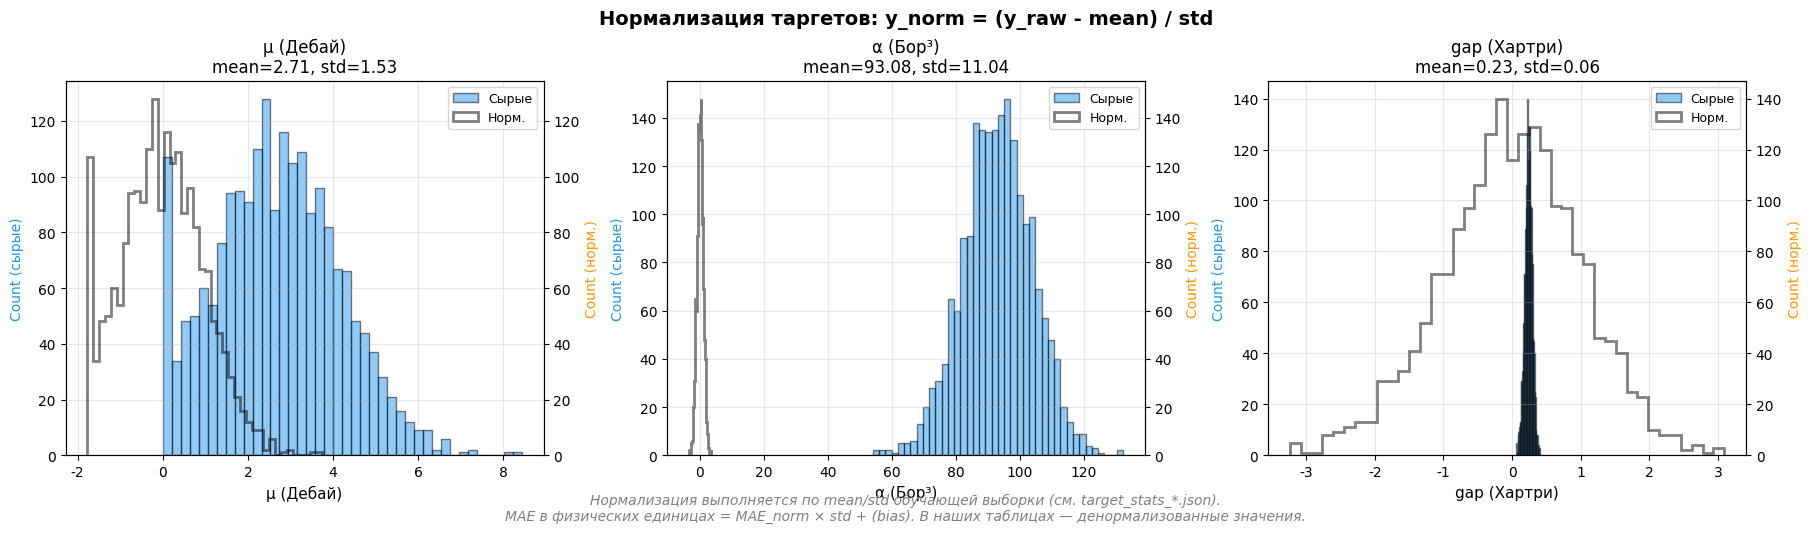

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle('Нормализация таргетов: y_norm = (y_raw - mean) / std',
             fontsize=14, fontweight='bold')

np.random.seed(7)
props = [
    ('mu',   'μ (Дебай)',   2.71,  1.53,  (0, 12)),
    ('alpha', 'α (Бор³)',   93.08, 11.04, (50, 200)),
    ('gap',  'gap (Хартри)', 0.235, 0.055, (0.05, 0.45)),
]

for ax, (k, label, mean, std, rng) in zip(axes, props):
    # Распределение «сырых» значений
    y_raw = np.random.normal(mean, std, 2000)
    y_raw = np.clip(y_raw, rng[0], rng[1])
    y_norm = (y_raw - mean) / std

    ax2 = ax.twinx()
    ax.hist(y_raw, bins=40, color='#2196F3', alpha=0.5, label='Сырые', edgecolor='black')
    ax2.hist(y_norm, bins=40, color='#FF9800', alpha=0.5, label='Норм.', edgecolor='black', histtype='step', linewidth=2)

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count (сырые)', color='#2196F3', fontsize=10)
    ax2.set_ylabel('Count (норм.)', color='#FF9800', fontsize=10)
    ax.set_title(f'{label}\nmean={mean:.2f}, std={std:.2f}', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Легенда
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=9, loc='upper right')

fig.text(0.5, -0.03,
         'Нормализация выполняется по mean/std обучающей выборки (см. target_stats_*.json).\n'
         'MAE в физических единицах = MAE_norm × std + (bias). В наших таблицах — денормализованные значения.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('12_target_normalization')
plt.show()


## График 13: Auto-ML модуль

Модуль `alchemy_geom_tda.automl` анализирует датасет и рекомендует архитектуру. Алгоритм: (1) проверить симметрии → (2) оценить TDA-признаки → (3) выдать рекомендацию.

  saved: results/figures/v35/13_automl.png


/tmp/ipykernel_2500/4121750732.py:26: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(p, dpi=150, facecolor='white', bbox_inches='tight')
/home/z/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


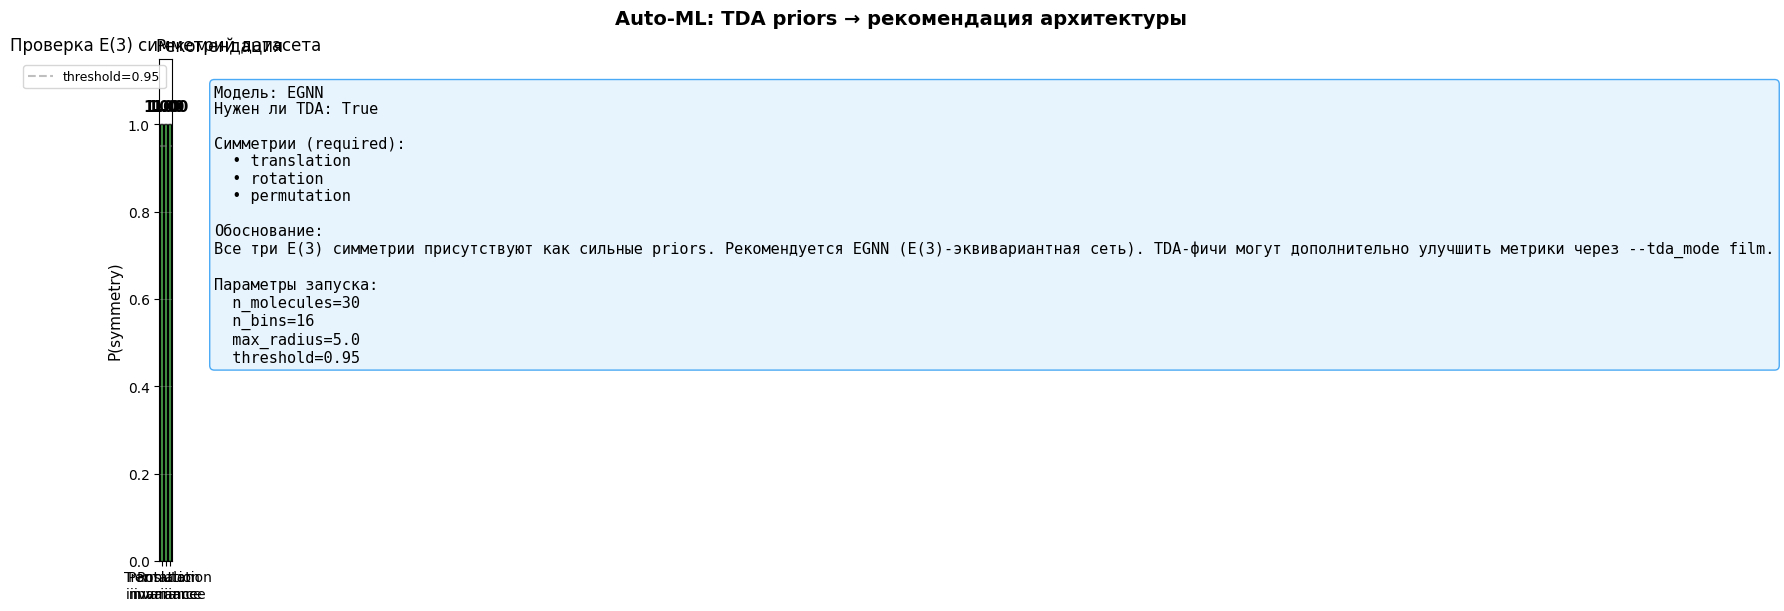

In [17]:
import json as _json
with open('results/automl/recommendation.json') as f:
    rec = _json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Auto-ML: TDA priors → рекомендация архитектуры',
             fontsize=14, fontweight='bold')

# Слева: индикаторы симметрий
ax = axes[0]
priors = rec['priors']
labels = ['Translation\ninvariance', 'Rotation\ninvariance', 'Permutation\ninvariance']
vals = [priors['translation_invariance'], priors['rotation_invariance'], priors['permutation_invariance']]
colors = ['#4CAF50' if v >= 0.95 else '#FF9800' if v >= 0.5 else '#F44336' for v in vals]
bars = ax.bar(labels, vals, color=colors, edgecolor='black')
ax.set_ylim(0, 1.15)
ax.set_ylabel('P(symmetry)', fontsize=11)
ax.set_title('Проверка E(3) симметрий датасета', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.03, f'{v:.2f}',
            ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='threshold=0.95')
ax.legend(fontsize=9)

# Справа: финальная рекомендация
ax = axes[1]
ax.axis('off')
ax.set_title('Рекомендация', fontsize=12)
txt = (
    f"Модель: {rec['recommendation']['recommended_model'].upper()}\n"
    f"Нужен ли TDA: {rec['recommendation']['needs_tda']}\n\n"
    f"Симметрии (required):\n"
    + ''.join(f'  • {s}\n' for s in rec['recommendation']['required_invariances'])
    + f"\nОбоснование:\n{rec['recommendation']['rationale']}\n\n"
    f"Параметры запуска:\n"
    f"  n_molecules={rec['args']['n_molecules']}\n"
    f"  n_bins={rec['args']['n_bins']}\n"
    f"  max_radius={rec['args']['max_radius']}\n"
    f"  threshold={rec['args']['threshold']}"
)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#E3F2FD', edgecolor='#2196F3', alpha=0.8))

savefig('13_automl')
plt.show()


## Финал

Все 13 графиков сохранены в `results/figures/v35/`. Эти PNG используются в HTML-презентации `download/alchemy_geom_tda_v35_presentation.html`.

In [18]:
import os
files = sorted(os.listdir(FIG_DIR))
print(f'Создано {len(files)} файлов в {FIG_DIR}/:')
for f in files:
    sz = os.path.getsize(os.path.join(FIG_DIR, f))
    print(f'  {f}  ({sz//1024} KB)')


Создано 13 файлов в results/figures/v35/:
  01_baselines_training.png  (306 KB)
  02_baselines_test.png  (90 KB)
  03_batch_size_impact.png  (167 KB)
  04_variants_test.png  (140 KB)
  05_tda_grouped.png  (102 KB)
  06_scalar_vs_vector_vs_tensor.png  (106 KB)
  07_tensor_training.png  (187 KB)
  08_params_time.png  (107 KB)
  09_tda_features.png  (61 KB)
  10_summary_table.png  (200 KB)
  11_parity_plots.png  (247 KB)
  12_target_normalization.png  (141 KB)
  13_automl.png  (119 KB)
